# EDA - Diabetes

## Objetivo
Realizar un análisis exploratorio inicial del dataset.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)


## 1. Carga del dataset


In [2]:
df = pd.read_csv('/content/diabetes.csv')
print('Shape:', df.shape)
print('Columnas:', df.columns.tolist())
display(df.head())
display(df.tail())
df.info()


Shape: (442, 11)
Columnas: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6', 'target']


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
437,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207,178.0
438,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018114,0.044485,104.0
439,0.041708,0.050680,-0.015906,0.017293,-0.037344,-0.013840,-0.024993,-0.011080,-0.046883,0.015491,132.0
440,-0.045472,-0.044642,0.039062,0.001215,0.016318,0.015283,-0.028674,0.026560,0.044529,-0.025930,220.0
441,-0.045472,-0.044642,-0.073030,-0.081413,0.083740,0.027809,0.173816,-0.039493,-0.004222,0.003064,57.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB


## 2. Estadísticas descriptivas


In [3]:
display(df.describe().T)

numericas = df.select_dtypes(include=['int64','float64']).columns.tolist()
categoricas = df.select_dtypes(include='object').columns.tolist()

print('Variables numéricas:', numericas)
print('Variables categóricas:', categoricas)


,count,mean,std,min,25%,50%,75%,max
age,442.0,-7.284269e-18,0.047619,-0.107226,-0.037299,0.005383,0.038076,0.110727
sex,442.0,2.348549e-17,0.047619,-0.044642,-0.044642,-0.044642,0.050680,0.050680
bmi,442.0,-2.087320e-16,0.047619,-0.090275,-0.034229,-0.007284,0.031248,0.170555
bp,442.0,-4.571507e-17,0.047619,-0.112399,-0.036656,-0.005670,0.035644,0.132044
s1,442.0,-9.293722e-18,0.047619,-0.126781,-0.034248,-0.004321,0.028358,0.153914
s2,442.0,4.420798e-17,0.047619,-0.115613,-0.030358,-0.003819,0.029844,0.198788
s3,442.0,2.135044e-18,0.047619,-0.102307,-0.035117,-0.006584,0.029312,0.181179
s4,442.0,2.913707e-17,0.047619,-0.076395,-0.039493,-0.002592,0.034309,0.185234
s5,442.0,9.143013e-17,0.047619,-0.126097,-0.033246,-0.001947,0.032432,0.133597
s6,442.0,1.431736e-17,0.047619,-0.137767,-0.033179,-0.001078,0.027917,0.135612


Variables numéricas: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6', 'target']
Variables categóricas: []


## 3. Distribución de variables categóricas


In [4]:
for col in categoricas:
    print('\n', col)
    display(df[col].value_counts(dropna=False))


## 4. Valores nulos y duplicados


In [5]:
print('Valores nulos por columna:')
display(df.isnull().sum())

duplicados = df.duplicated().sum()
print('Filas duplicadas:', duplicados)
print('Porcentaje:', round(duplicados / len(df) * 100, 2), '%')


Valores nulos por columna:


,0
age,0
sex,0
bmi,0
bp,0
s1,0
s2,0
s3,0
s4,0
s5,0
s6,0


Filas duplicadas: 0
Porcentaje: 0.0 %


## 5. Histogramas


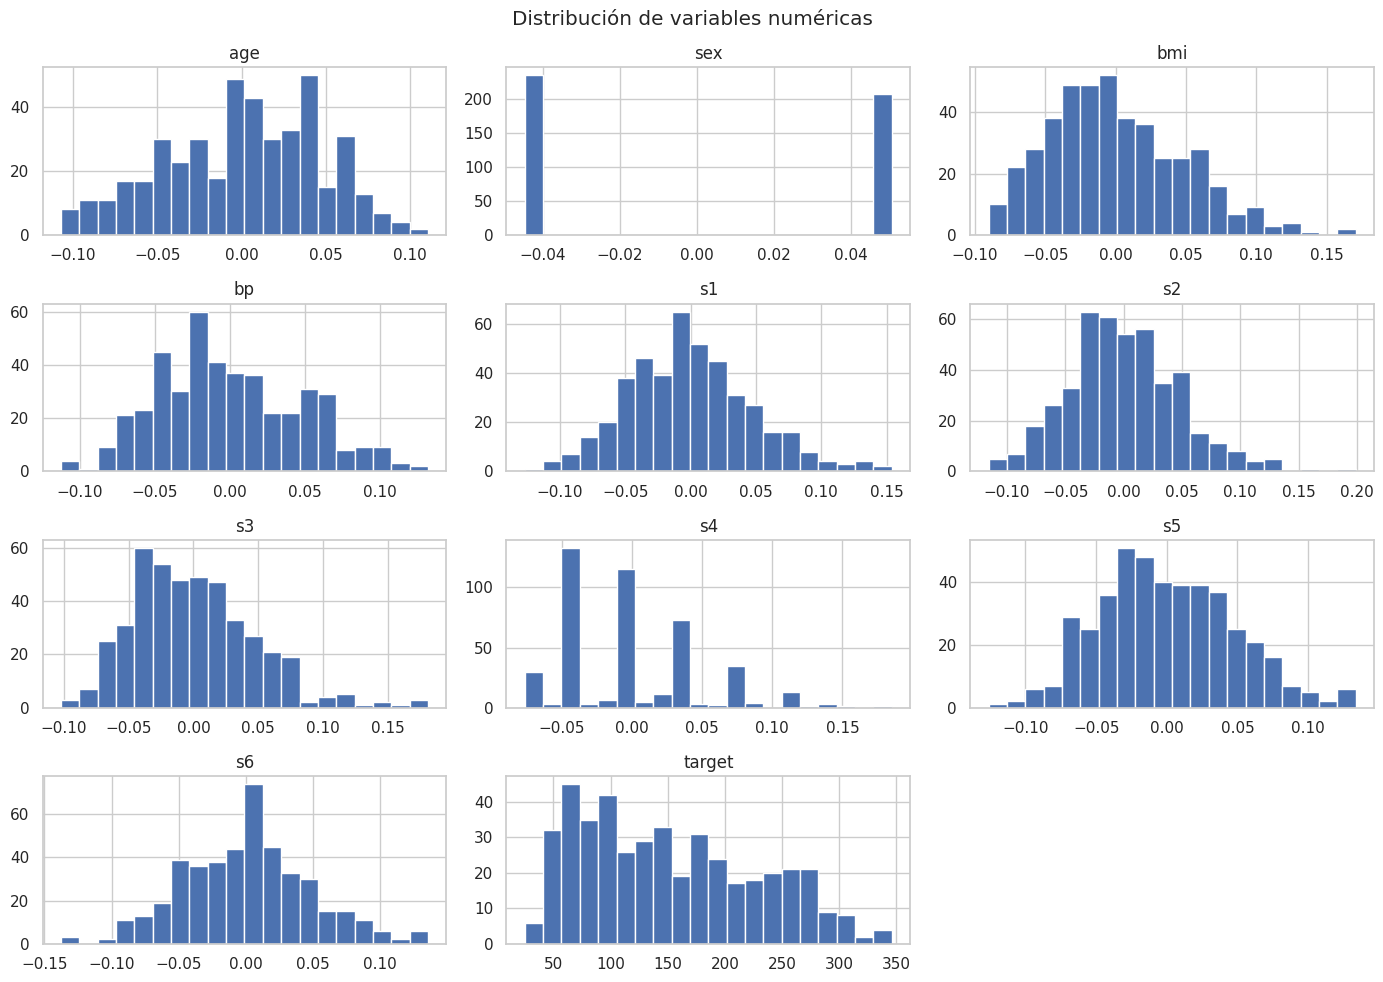

In [6]:
df[numericas].hist(figsize=(14,10), bins=20)
plt.suptitle('Distribución de variables numéricas')
plt.tight_layout()
plt.show()


## 6. Gráficos de barras


In [7]:
if len(categoricas) > 0:
    for col in categoricas:
        plt.figure(figsize=(7,4))
        sns.countplot(data=df, x=col, hue=col, palette='Set2', legend=False)
        plt.title('Distribución de ' + col)
        plt.xticks(rotation=45)
        plt.show()
else:
    print('No hay variables categóricas de tipo object.')


No hay variables categóricas de tipo object.


## 7. Boxplots e identificación de outliers


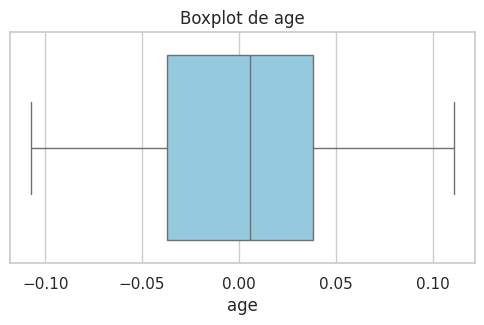

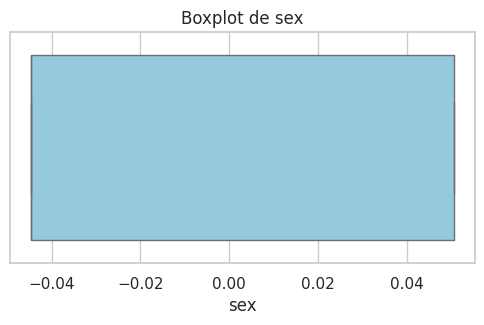

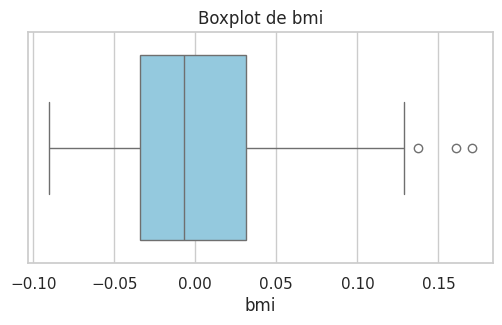

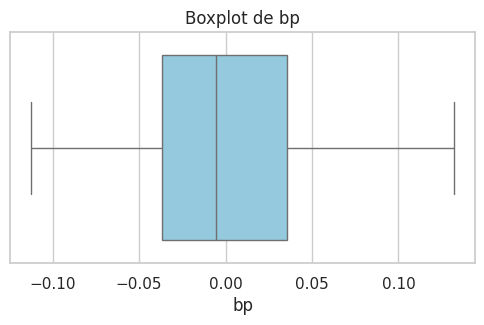

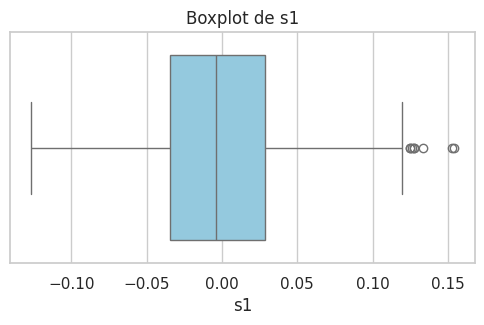

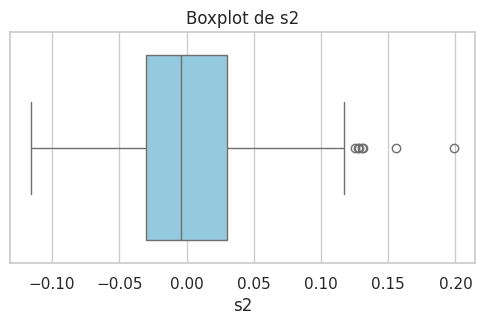

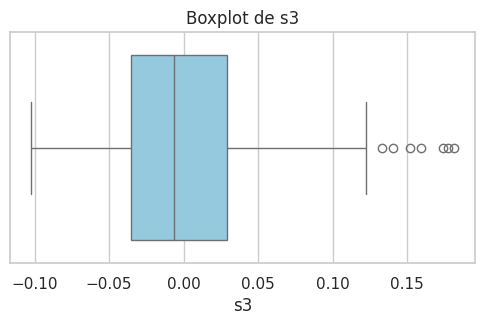

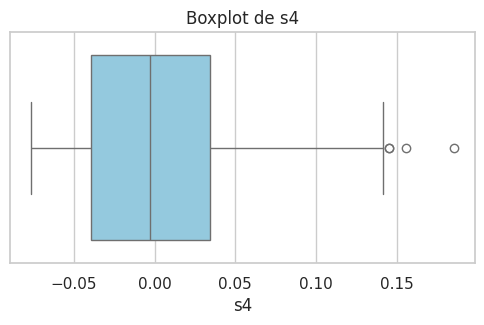

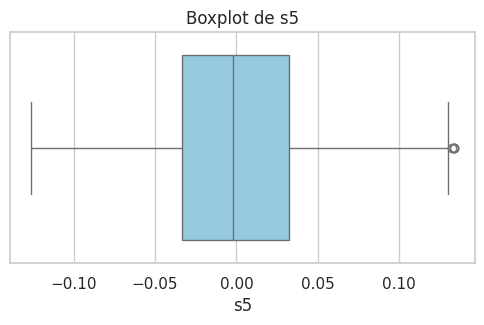

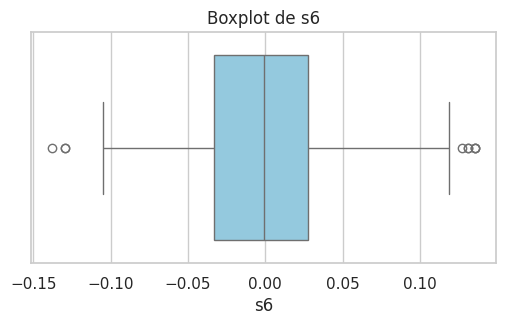

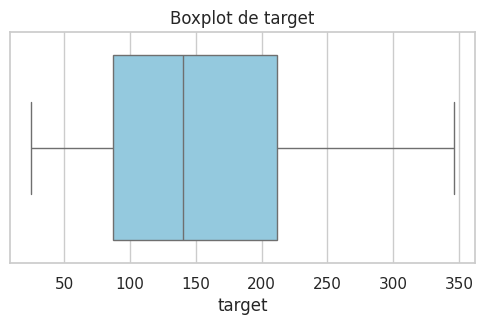

age : 0 outliers
sex : 0 outliers
bmi : 3 outliers
bp : 0 outliers
s1 : 8 outliers
s2 : 7 outliers
s3 : 7 outliers
s4 : 4 outliers
s5 : 4 outliers
s6 : 9 outliers
target : 0 outliers


In [8]:
for col in numericas:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col], color='skyblue')
    plt.title('Boxplot de ' + col)
    plt.show()

for col in numericas:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    inferior = Q1 - 1.5 * IQR
    superior = Q3 + 1.5 * IQR
    cantidad = ((df[col] < inferior) | (df[col] > superior)).sum()
    print(col, ':', cantidad, 'outliers')


## 8. Mapa de calor de correlación


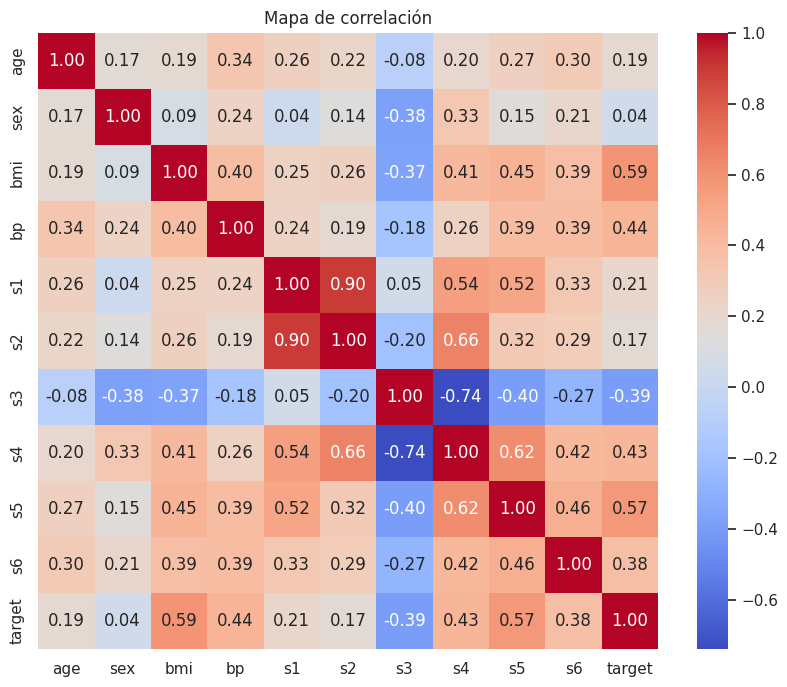

In [9]:
plt.figure(figsize=(10,8))
sns.heatmap(df[numericas].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Mapa de correlación')
plt.show()


## 9. Diagnóstico inicial

**Tipo de problema sugerido:** Regresión.

**Variable objetivo sugerida:** `target`.

**Resumen:** Dataset adecuado para practicar EDA, preprocesamiento y modelado inicial.
